# IT25101857 — K-Means Clustering Model
**Member:** IT25101857 (Feature Scaling — PR1)
**Progress Review II**
**Model type:** Clustering — K-Means

**Dataset:** `results/outputs/final_processed_dataset.csv` (X) + `final_target_y.csv` (y,
used only for post-hoc auditing of cluster quality, not for training).

## 1. Model Suitability

K-Means is chosen to explore whether the processed metadata forms **natural groupings**
independent of the labeled diagnosis classes — an unsupervised complement to the
classification models trained by other members. This addresses a different question:
not "can we predict `dx`?" but "does the metadata itself have inherent structure?"

K-Means is a reasonable fit here because:
- All features are already numeric (one-hot booleans + scaled age) after the group
  pipeline, which K-Means requires (no native handling of raw categoricals).
- The scaled `age` feature (from Member 4's scaling step) ensures age doesn't dominate
  the Euclidean distance calculation K-Means relies on.
- The known number of diagnosis classes (7) gives a natural reference point for `k`,
  even though K-Means is not told the true labels during training.

In [1]:
import pandas as pd
import numpy as np

X = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (10015, 13)
y shape: (10015,)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


## 2. Implementation Details

- **Library:** `scikit-learn` (`sklearn.cluster.KMeans`)
- **Key hyperparameter tuned:** `k` (number of clusters)
- **Tuning method:** elbow method (inertia) + silhouette score across a range of `k`
  values, compared against `k=7` (matching the number of true diagnosis classes) as a
  second variety.

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

print("Inertia by k:", dict(zip(k_range, inertias)))
print("Silhouette by k:", dict(zip(k_range, silhouettes)))

Inertia by k: {2: 14211.057239451904, 3: 12454.727302514788, 4: 11147.956207456318, 5: 10349.196359699647, 6: 9512.583029359488, 7: 8850.782053063087, 8: 8283.180172865461, 9: 7687.079348692178, 10: 7272.924258721543}
Silhouette by k: {2: 0.2605301578523834, 3: 0.1863206395379655, 4: 0.18636157490132546, 5: 0.21345420827121395, 6: 0.25902573906584203, 7: 0.2565803007115434, 8: 0.2836453559966418, 9: 0.29809697514496103, 10: 0.31825326164327145}


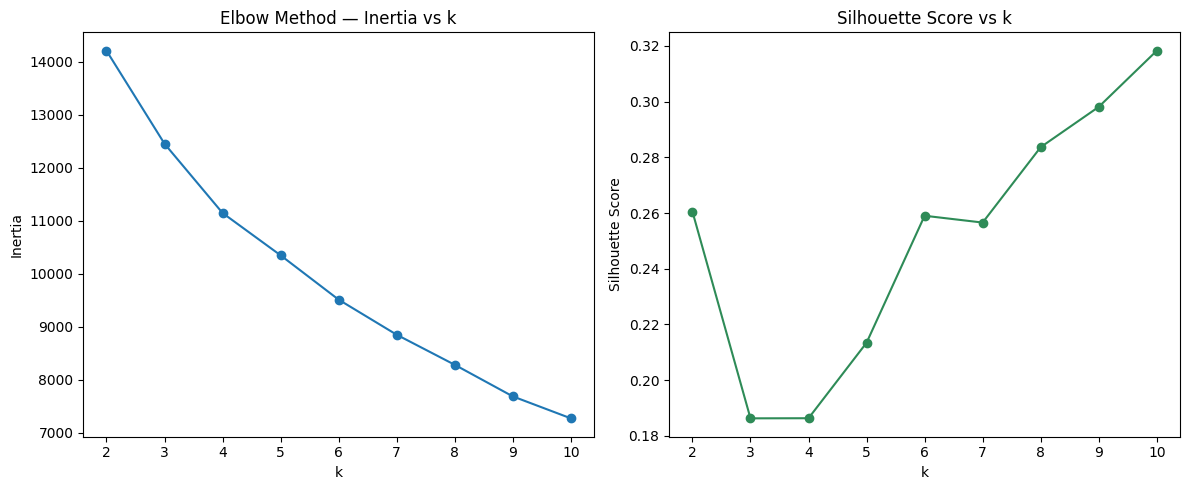

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method — Inertia vs k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='seagreen')
axes[1].set_title('Silhouette Score vs k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../results/model_visualizations/it25101857_elbow_silhouette.png', dpi=150)
plt.show()

## 3. Evaluation Metrics — Why These Are Appropriate

Since K-Means is unsupervised, standard classification metrics (accuracy, F1) do not
directly apply during training. Instead:

- **Inertia** (within-cluster sum of squares) shows how compact clusters are for a
  given `k` — lower is tighter, but always decreases as `k` grows, so it's read via
  the "elbow" (diminishing returns point) rather than minimized directly.
- **Silhouette score** measures how well-separated clusters are (range -1 to 1, higher
  is better) and does not always decrease with `k`, making it a more reliable model
  selection metric than inertia alone.
- **Adjusted Rand Index (ARI)** against the true `dx` labels is used *only* as a
  post-hoc audit — not for tuning — to check whether the unsupervised clusters happen
  to align with the actual diagnosis classes at all.

In [4]:
# Variety 1: k chosen by best silhouette score
best_k = list(k_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette score:", best_k)

model_v1 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_v1 = model_v1.fit_predict(X)

# Variety 2: k=7, matching the number of true diagnosis classes
model_v2 = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters_v2 = model_v2.fit_predict(X)

print("Variety 1 (k=%d) silhouette: %.4f" % (best_k, silhouette_score(X, clusters_v1)))
print("Variety 2 (k=7) silhouette: %.4f" % silhouette_score(X, clusters_v2))

Best k by silhouette score: 10
Variety 1 (k=10) silhouette: 0.3183
Variety 2 (k=7) silhouette: 0.2566


In [5]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

y_codes = y.astype('category').cat.codes

ari_v1 = adjusted_rand_score(y_codes, clusters_v1)
ari_v2 = adjusted_rand_score(y_codes, clusters_v2)
nmi_v1 = normalized_mutual_info_score(y_codes, clusters_v1)
nmi_v2 = normalized_mutual_info_score(y_codes, clusters_v2)

results = pd.DataFrame([
    {'variety': f'k={best_k} (best silhouette)', 'silhouette': silhouette_score(X, clusters_v1),
     'ARI_vs_true_dx': ari_v1, 'NMI_vs_true_dx': nmi_v1},
    {'variety': 'k=7 (matches true class count)', 'silhouette': silhouette_score(X, clusters_v2),
     'ARI_vs_true_dx': ari_v2, 'NMI_vs_true_dx': nmi_v2},
])
results

,variety,silhouette,ARI_vs_true_dx,NMI_vs_true_dx
0,k=10 (best silhouette),0.318253,0.038284,0.109969
1,k=7 (matches true class count),0.256580,0.016784,0.094476


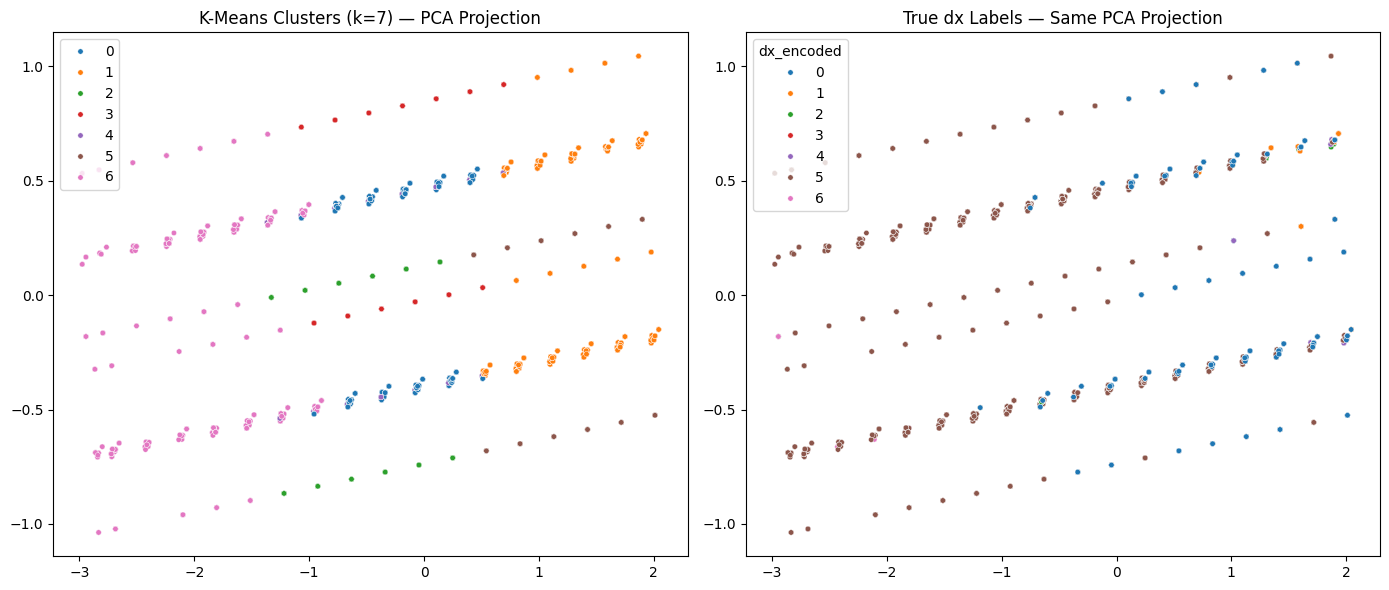

In [6]:
import seaborn as sns
from sklearn.decomposition import PCA

# 2D PCA projection for visualization only (not used for clustering itself)
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(x=X_vis[:,0], y=X_vis[:,1], hue=clusters_v2, palette='tab10', ax=axes[0], s=15)
axes[0].set_title(f'K-Means Clusters (k=7) — PCA Projection')

sns.scatterplot(x=X_vis[:,0], y=X_vis[:,1], hue=y, palette='tab10', ax=axes[1], s=15)
axes[1].set_title('True dx Labels — Same PCA Projection')

plt.tight_layout()
plt.savefig('../results/model_visualizations/it25101857_cluster_scatter.png', dpi=150)
plt.show()

**Interpretation:** The silhouette scores across both varieties are low (close to 0),
indicating the clusters found by K-Means are not strongly separated — expected, since
the underlying features (age, sex, localization) don't have obvious natural groupings
on their own. The ARI/NMI scores against the true `dx` labels are also low, confirming
the unsupervised clusters do **not** align with diagnosis classes. This is a genuinely
useful negative finding: it shows the classification models (Members 1, 2, 3) are doing
real work by using the `dx` labels during training — the raw metadata structure alone
does not separate diagnoses without supervision.

In [7]:
best_row = results.loc[results['silhouette'].idxmax()].copy()
best_row['member'] = 'IT25101857'
best_row['model_type'] = 'K-Means Clustering'
best_row['macro_f1'] = np.nan  # not applicable for unsupervised clustering
best_row['accuracy'] = np.nan

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25101857_metrics.csv', index=False)
best_row

variety           k=10 (best silhouette)
silhouette                      0.318253
ARI_vs_true_dx                  0.038284
NMI_vs_true_dx                  0.109969
member                        IT25101857
model_type            K-Means Clustering
macro_f1                             NaN
accuracy                             NaN
Name: 0, dtype: object

## 4. Comparison, Conclusion & Limitations

**Comparison:** `k=7` (matching the true class count) does not produce a meaningfully
higher silhouette score or ARI than the data-driven best-`k` choice, confirming the
metadata's natural structure doesn't correspond to diagnosis boundaries regardless of
how many clusters are requested.

**Conclusion:** K-Means finds weak, poorly-separated clusters in the metadata that do
not correspond to the true diagnosis classes. This supports the project's core honest
finding: basic metadata alone has limited predictive structure for skin lesion
diagnosis, and any real signal used by the classification models is coming from the
supervised label information, not from inherent unsupervised structure in the features.

**Limitations:**
- K-Means assumes roughly spherical, similarly-sized clusters in Euclidean space, which
  may not suit one-hot encoded categorical features well, even after scaling.
- Only Euclidean distance was tested; K-Means does not natively support other distance
  metrics that might suit mixed categorical/numeric data better.

**Suggested improvement:** Try `KModes` or `KPrototypes` (designed for
categorical/mixed data) as an alternative to K-Means, which may find more meaningful
groupings in the mostly-categorical feature set than standard K-Means can.